# ---------------------------------------------------------
# EXPLICACIÓN DEL ALGORITMO TABU SEARCH
# ---------------------------------------------------------
#
# Tabu Search es una metaheurística de búsqueda local que
# mejora progresivamente una solución explorando soluciones
# vecinas. En el problema TSP, los vecinos se generan
# intercambiando la posición de dos ciudades dentro de la ruta.
#
# A diferencia de una búsqueda local tradicional, Tabu Search
# incorpora una memoria llamada "Lista Tabú". Esta memoria
# almacena las soluciones visitadas recientemente para evitar
# que el algoritmo vuelva constantemente a los mismos estados.
#
# Sin esta memoria, el algoritmo podría caer fácilmente en
# ciclos, por ejemplo:
#
# Ruta A -> Ruta B -> Ruta A -> Ruta B -> Ruta A
#
# provocando que la búsqueda se estanque y no explore nuevas
# regiones del espacio de soluciones.
#
# La Lista Tabú permite forzar la exploración de alternativas
# diferentes, aumentando la diversidad de la búsqueda y
# reduciendo la probabilidad de quedar atrapado en mínimos
# locales.
#
# El parámetro más importante de Tabu Search es el tamaño de
# la memoria tabú (tamano_lista_tabu).
#
# Si la memoria es muy pequeña:
# - El algoritmo olvida rápidamente.
# - Puede volver a visitar rutas recientes.
# - Existe mayor riesgo de ciclos.
#
# Si la memoria es muy grande:
# - Se evita mejor la repetición.
# - Se exploran más regiones distintas.
# - Algunas rutas potencialmente buenas pueden quedar
#   bloqueadas temporalmente.
#
# En esta implementación se utiliza una memoria de 10
# soluciones, ya que proporciona un equilibrio adecuado entre
# exploración y explotación para un problema de 16 ciudades.
#
# También se utilizan 100 iteraciones, permitiendo que el
# algoritmo disponga de suficientes oportunidades para mejorar
# la solución encontrada sin aumentar excesivamente el tiempo
# de ejecución.
#
# La principal característica de Tabu Search es que su memoria
# guía la búsqueda. Mientras otros algoritmos toman decisiones
# únicamente basadas en el estado actual, Tabu Search utiliza
# información de soluciones anteriores para decidir hacia dónde
# continuar explorando.
#
# ---------------------------------------------------------

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import math

ciudades = np.array([

    # Grupo A
    (10,10),
    (12,11),
    (11,13),
    (14,12),

    # Grupo B
    (45,45),
    (47,46),
    (44,48),
    (46,50),

    # Grupo C
    (85,15),
    (88,18),
    (86,21),
    (90,17),

    # Ciudades puente
    (30,25),
    (60,30),

    # Ciudades conflictivas
    (55,70),
    (25,60)

])

n_ciudades = len(ciudades)

print("Cantidad de ciudades:", n_ciudades)

Cantidad de ciudades: 16


In [ ]:
def distancia(a, b):
    return np.linalg.norm(a - b)

In [ ]:
dist_matrix = np.array([
    [distancia(ciudades[i], ciudades[j]) for j in range(n_ciudades)]
    for i in range(n_ciudades)
])

In [ ]:
def costo(ruta):
    return sum(dist_matrix[ruta[i]][ruta[i+1]] for i in range(len(ruta)-1)) + dist_matrix[ruta[-1]][ruta[0]]

In [ ]:
def plot_ruta(ruta, titulo="Ruta"):
    r = np.array([ciudades[i] for i in ruta] + [ciudades[ruta[0]]])

    plt.figure()
    plt.plot(r[:,0], r[:,1], marker='o')
    plt.title(titulo)
    plt.show()

In [ ]:
def tabu_search(iteraciones=100, tamano_lista_tabu=10):
    actual = random.sample(range(n_ciudades), n_ciudades)
    mejor = actual[:]

    lista_tabu = []

    for _ in range(iteraciones):
        vecinos = []

        for i in range(n_ciudades):
            for j in range(i+1, n_ciudades):
                vecino = actual[:]
                vecino[i], vecino[j] = vecino[j], vecino[i]

                if vecino not in lista_tabu:
                    vecinos.append(vecino)

        if not vecinos:
            break

        mejor_vecino = min(vecinos, key=costo)
        actual = mejor_vecino

        if costo(actual) < costo(mejor):
            mejor = actual[:]

        lista_tabu.append(actual)

        if len(lista_tabu) > tamano_lista_tabu:
            lista_tabu.pop(0)

    return mejor

In [ ]:
import time

inicio = time.time()

ruta_tabu = tabu_search(
    iteraciones=100,
    tamano_lista_tabu=10
)

fin = time.time()

costo_tabu = costo(ruta_tabu)
tiempo_tabu = fin - inicio

print("===== TABU SEARCH =====\n")

print("Ruta encontrada:")
print(ruta_tabu)

print("\nCosto total:")
print(round(costo_tabu, 2))

print("\nIteraciones:")
print(100)

print("\nMemoria Tabú:")
print(10)

print("\nTiempo:")
print(round(tiempo_tabu, 4), "segundos")

===== TABU SEARCH =====

Ruta encontrada:
[9, 10, 13, 5, 7, 14, 15, 6, 4, 12, 2, 0, 1, 3, 8, 11]

Costo total:
268.84

Iteraciones:
100

Memoria Tabú:
10

Tiempo:
0.1102 segundos


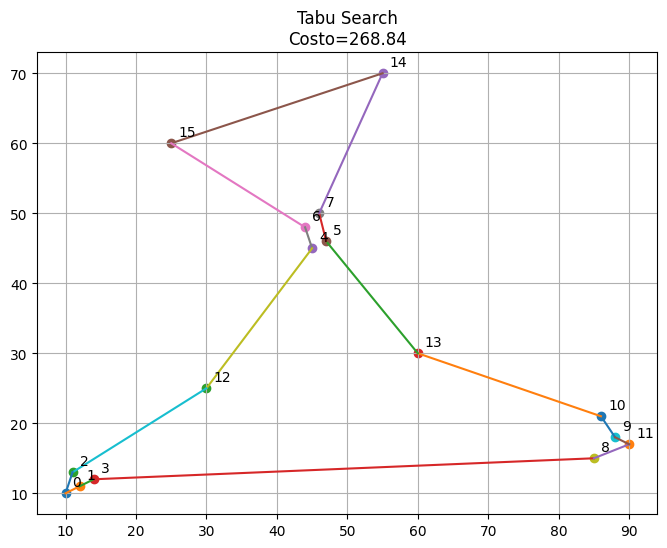

In [ ]:
plt.figure(figsize=(8,6))

ruta_cerrada = ruta_tabu + [ruta_tabu[0]]

for i in range(len(ruta_cerrada)-1):

    origen = ruta_cerrada[i]
    destino = ruta_cerrada[i+1]

    x1, y1 = ciudades[origen]
    x2, y2 = ciudades[destino]

    plt.plot(
        [x1, x2],
        [y1, y2]
    )

for indice, (x,y) in enumerate(ciudades):

    plt.scatter(x,y)

    plt.text(
        x + 1,
        y + 1,
        str(indice)
    )

plt.title(
    f"Tabu Search\nCosto={round(costo_tabu,2)}"
)

plt.grid(True)

plt.show()

#Tabu Search parte con una ruta aleatoria y trata de mejorarla gradualmente mediante intercambios entre ciudades. En cada iteración analiza muchas variantes de la ruta actual y selecciona la mejor opción disponible. Este proceso se repite durante 100 iteraciones, permitiendo que la solución vaya mejorando progresivamente. La lista tabú evita regresar a rutas visitadas recientemente, favoreciendo la exploración de nuevas alternativas.